# Temperature profile above the main engine — `warm_M5` ventilation-timing comparison

T(z) over the main-engine centre (x=6.75, y≈7.1) from the engine top z=2.0 m to the
ceiling z=3.0 m, time-averaged over the steady window. Same method as
`plot_engine_temp.py`: XZ TEMPERATURE slice (PBY≈7.1, orientation 2), value at the x
column nearest the engine centre; error band = temporal std over the window.

Three cases overlaid (ventilation starts at **20 / 40 / 60 s**). Runs stopped at the
6 h SLURM time limit (v40→221 s), so the average uses **t = 150–200 s** (common coverage).


In [1]:
import warnings; warnings.filterwarnings("ignore")
import logging;  logging.disable(logging.CRITICAL)
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import fdsreader

plt.rcParams.update({"axes.labelsize": 16, "axes.titlesize": 17,
                     "xtick.labelsize": 13, "ytick.labelsize": 13,
                     "legend.fontsize": 13})
print("fdsreader", fdsreader.__version__)

fdsreader 1.11.7


In [12]:
RES = Path("/shared/home/wel1come1234/workspace/FDS/Engineroom/Results")
OUT = Path("/shared/home/wel1come1234/workspace/FDS/Engineroom/Analysis/flame")
OUT.mkdir(parents=True, exist_ok=True)

# case dir -> (legend label, colour, HRR peak time s)  ordered by peak time
# Vents run from t=0 in every case; the only varied knob is the HRR t^2
# time-to-peak (5/10/15/20 s).
CASES = {
    "peak05_M5": ("peak @5 s",  "#2980b9",  5),
    "peak10_M5": ("peak @10 s", "#27ae60", 10),
    "peak15_M5": ("peak @15 s", "#e67e22", 15),
    "peak20_M5": ("peak @20 s", "#8e44ad", 20),
}

CASES = {
    "peak05_fire1_M5": ("peak @5 s",  "#2980b9",  5),
    "peak10_fire1_M5": ("peak @10 s", "#27ae60", 10),
    "peak15_fire1_M5": ("peak @15 s", "#e67e22", 15),
    "peak20_fire1_M5": ("peak @20 s", "#8e44ad", 20),
}

X_ENG    = 6.75            # main-engine centre x
Y_TARGET = 7.1            # main-engine centre y (XZ slice plane)
Z_LO     = 2.0            # engine top
Z_HI     = 3.0            # ceiling
WIN      = (100.0, 360.0)  # steady-state averaging window (full 360 s coverage)
REF_CSV  = "engine_ref.csv"  # optional reference (z, T) - plotted if present


In [13]:
def engine_temp_profile(sim):
    """T(z) over the engine centre from the XZ TEMPERATURE slice, averaged over WIN.
    Returns (z_sel, T_avg, T_std, y_slice)."""
    xz = [s for s in sim.slices
          if s.orientation == 2 and "TEMP" in s.quantity.name.upper()]
    if not xz:
        raise RuntimeError("No XZ temperature slice found")
    sl  = min(xz, key=lambda s: abs(s.extent.y_start - Y_TARGET))
    ext = sl.extent

    T_all = sl.to_global(masked=True, fill=np.nan)             # (t, x, z)
    t_arr = np.asarray(sl.times)
    x_arr = np.linspace(ext.x_start, ext.x_end, T_all.shape[1])
    z_arr = np.linspace(ext.z_start, ext.z_end, T_all.shape[2])

    ix    = int(np.argmin(np.abs(x_arr - X_ENG)))
    iz_lo = int(np.searchsorted(z_arr, Z_LO))
    iz_hi = int(np.searchsorted(z_arr, Z_HI, side="right")) - 1
    z_sel = z_arr[iz_lo:iz_hi + 1]

    t0   = WIN[0]
    t1   = min(WIN[1], float(t_arr.max()))
    mask = (t_arr >= t0) & (t_arr <= t1)
    if not mask.any():
        mask = np.array([int(np.argmax(t_arr))])

    T_win = T_all[np.ix_(mask, [ix], np.arange(iz_lo, iz_hi + 1))]
    T_avg = np.nanmean(T_win, axis=0)[0]
    T_std = np.nanstd(T_win, axis=0)[0]
    return z_sel, T_avg, T_std, float(ext.y_start)

In [14]:
results = {}
for case, (label, color, vs) in CASES.items():
    sim = fdsreader.Simulation(str(RES / case))
    z, T, Tstd, ysl = engine_temp_profile(sim)
    results[case] = dict(label=label, color=color, vent=vs,
                         z=z, T=T, Tstd=Tstd, y=ysl)
    print(f"{label:12s}: y_slice={ysl:.3f} m, "
          f"T={np.nanmin(T):.1f}-{np.nanmax(T):.1f} C, std_max={np.nanmax(Tstd):.2f}")

peak @5 s   : y_slice=7.080 m, T=65.6-107.8 C, std_max=7.85
peak @10 s  : y_slice=7.080 m, T=65.5-106.2 C, std_max=7.79
peak @15 s  : y_slice=7.080 m, T=65.6-105.3 C, std_max=6.67
peak @20 s  : y_slice=7.080 m, T=65.3-105.3 C, std_max=7.97


In [15]:
# steady-state engine-top temperatures (averaged over WIN)
print(f"Engine-top T(z) averaged over {WIN[0]:.0f}-{WIN[1]:.0f} s:\n")
print(f"{'case':12s} {'T@z=2.0':>9s} {'T@z=2.5':>9s} {'T@z=3.0(ceil)':>14s}")
for case, r in results.items():
    z, T = r["z"], r["T"]
    def at(zt): return T[int(np.argmin(np.abs(z - zt)))]
    print(f"{r['label']:12s} {at(2.0):9.1f} {at(2.5):9.1f} {at(3.0):14.1f}")

Engine-top T(z) averaged over 100-360 s:

case           T@z=2.0   T@z=2.5  T@z=3.0(ceil)
peak @5 s         65.6      77.8          107.8
peak @10 s        65.5      77.3          106.2
peak @15 s        65.6      77.7          105.3
peak @20 s        65.3      77.1          105.3


reference loaded: engine_ref.csv
-> /shared/home/wel1come1234/workspace/FDS/Engineroom/Analysis/flame/engine_temp_profile_compare.png


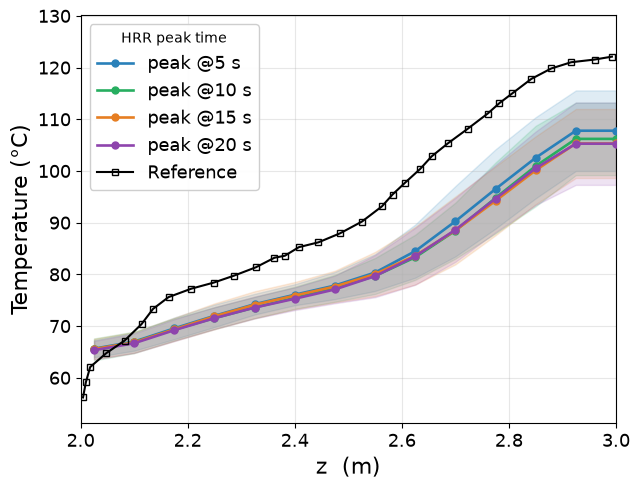

In [16]:
ref = None
p = OUT / REF_CSV
if p.exists():
    ref = np.loadtxt(p, delimiter=",")
    print("reference loaded:", REF_CSV)
else:
    print("no reference CSV (", REF_CSV, ") — plotting cases only")

fig, ax = plt.subplots(figsize=(6.5, 5))
for case, r in results.items():
    z, T, Tstd = r["z"], r["T"], r["Tstd"]
    ax.plot(z, T, "-o", color=r["color"], lw=1.9, ms=5, label=r["label"], zorder=3)
    ax.fill_between(z, T - Tstd, T + Tstd, color=r["color"], alpha=0.15, zorder=1)
if ref is not None:
    # engine_ref.csv columns assumed (T, z) as in plot_engine_temp.py
    ax.plot(ref[:, 1], ref[:, 0], "k-s", lw=1.5, ms=5, mfc="none",
            label="Reference", zorder=5)

ax.set_xlabel("z  (m)")
ax.set_ylabel("Temperature (\u00b0C)")
ax.set_xlim(Z_LO, Z_HI)
lo = min(np.nanmin(r["T"] - r["Tstd"]) for r in results.values())
hi = max(np.nanmax(r["T"] + r["Tstd"]) for r in results.values())
if ref is not None:                       # keep the full reference curve in view
    lo = min(lo, float(ref[:, 0].min()))
    hi = max(hi, float(ref[:, 0].max()))
ax.set_ylim(max(0, lo - 5), hi + 8)
ax.grid(alpha=0.3)
ax.legend(loc="upper left", framealpha=0.95, title="HRR peak time")
fig.tight_layout()
out = OUT / "engine_temp_profile_compare.png"
fig.savefig(out, dpi=150)
print("->", out)
plt.show()